<a href="https://colab.research.google.com/github/ArthurCBx/Applied_MachineLearning_in_Python/blob/main/Module3/Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Evaluation & Selection

## Learning Objectives
- Understand why accuracy only gives a partial picture of a classifier's performance;
- Understand the motivation and definition of important evaluation metrics in machine learning;
- Learn how to use a variety of evaluation metrics to evaluate supervise ML models;
- Learn about choosing the right metric for selecting between models or for doing parameter tuning.

## Evaluation
- Different applications have very different goals;
- Accuracy is widely used, but many others are possible, e.g.:
  - User satisfaction (Web searc);
  - Amount of revenue (e-commerce);
  - Increase in patient survival rates (medical).
- It's very important to choose evaluation methods that match the goal of your application;
- Compute your selected evaluation metric for multiple different models. Then select the model with 'best value of evaluation;

## Accuracy with Imbalanced Classes
- Suppose you have 2 classes:
  - Relevant(R)
  - Not_Relevant(N)
- Out of 1000 randomly selected items, on average:
  - One item is relevant and has an R label;
  - The rest (999) are not relevant and labelled N.
- Recall that:
$Accuracy = \frac{\#correct \, prediction}{\#total \, instances}$

### Example
- Suppose you build a classifier to predict relevant items and see that its accuracy on a test set is 99.9%. But for comparison, if we had a "dummy" classifier that didn't look at the features at all, and always just blindly predicted the mos frequent class (i.e. the N class).
- With a test set of 1000 instances, the accuract of the dummy classifier is 99.9%

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

dataset = load_digits()
X, y = dataset.data, dataset.target

for class_name, class_count in zip(dataset.target_names, np.bincount(dataset.target)):
  print(f'target {class_name}: count {class_count}')

target 0: count 178
target 1: count 182
target 2: count 177
target 3: count 183
target 4: count 181
target 5: count 182
target 6: count 181
target 7: count 179
target 8: count 174
target 9: count 180


In [ ]:
y_binary_imbalanced = y.copy()
y_binary_imbalanced[y_binary_imbalanced != 1] = 0
np.bincount(y_binary_imbalanced)

array([1615,  182])

In [ ]:
# Creating a SVC classifier
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(X, y_binary_imbalanced, random_state=0)
svm = SVC(kernel='rbf', C=0.01).fit(X_train, y_train)
svm.score(X_test, y_test)

0.9044444444444445

In [ ]:
# Using a dummy classifier
from sklearn.dummy import DummyClassifier

dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)

y_dummy_predictions = dummy_majority.predict(X_test)

# Output is always 0
y_dummy_predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
dummy_majority.score(X_test, y_test)

0.9044444444444445

## Dummy classifiers completely ignore the input data
- They serve as a sanity check on your classifier's performance;
- They provide a null metric (e.g. null accuracy baseline);
- Dummy classifiers should not be used for real problems;

- Commonly used settings for the strategy are:
  - most_frequent;
  - stratified: random predictions based on training set class distribution;
  - uniform: generates predictions uniformly at random;
  - constant: always predict a constant label provided by the user


## What if my classifier accuracy is close to the null accuracy baseline?

This could be a sign of:
- Ineffective, erroneous or missing features;
- Poor choice of kernel or hyperparameter;
- Large class imbalance.

In [ ]:
svm = SVC(kernel='rbf', C=1).fit(X_train, y_train)
svm.score(X_test, y_test)

0.9955555555555555

## Dummy Regressors
Strategy parameter options:
- mean;
- median;
- quantile: predicts a user-provided quantile of the training targets;
- constant;

## Binary Prediction Outcomes:
1. TN (true negative)
2. FP (false positive - Type I error)
3. FN (false negative - Type II error)
4. TP (true positive)

### Confusion Matrix for Binary prediction Task

In [ ]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, y_dummy_predictions)

# Diagonal values represent successful classification
# TN FP
# FN TP
print('Most frequent class (dummy classifier)\n', confusion)

Most frequent class (dummy classifier)
 [[407   0]
 [ 43   0]]


In [ ]:
svm_predicted = svm.predict(X_test)
confusion = confusion_matrix(y_test, svm_predicted)
print('Support Vector Machine Classifier\n', confusion)

Support Vector Machine Classifier
 [[407   0]
 [  2  41]]


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000).fit(X_train, y_train)
lr_predicted = lr.predict(X_test)
confusion = confusion_matrix(y_test, lr_predicted)

print('Logistic regression classifier (default settings)\n', confusion)

Logistic regression classifier (default settings)
 [[403   4]
 [  7  36]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
tree_predicted = dt.predict(X_test)
confusion = confusion_matrix(y_test, tree_predicted)

print('Decision tree classifier (max_depth = 2)\n', confusion)

Decision tree classifier (max_depth = 2)
 [[400   7]
 [ 17  26]]


# Confusion Matrices & Basic Evaluation Metrics

## Classification error (I - Accuracy)
- For what fraction of all instances is the classifier's prediction incorrect?
- $ClassificationError = \frac{FP+FN}{TN+TP+FN+FP}$

## Recall or True Positive Rate (TPR)
- What fraction of all positive instances does the classifier correctly identify as positive?
- $Recall = \frac{TP}{TP+FN}$

## Precision
- What fraction of positive predictions are correct?
- $Precision = \frac{TP}{TP+FP}$

## False Positive rate (FPR)
- What fraction of all negative instances does the classifier incorrectly identify as positive?
- $FPR = \frac{FP}{TN+FP}$

## How to decide what metric to apply
- Is it more important to avoid false positives or false negatives?
- Precision is used as a metric when our objective is to minimize false positives;
- Recall is used when the objective is to minimize false negatives;
- E.g. of minimizing false positives (Precision-oriented task) is an algorithm that finds likely criminals in a given area.
- E.g. of minimizing false negatives (recall-oriented task) is trying to find all emails that mention a certain event.

### Recall-oriented machine learning tasks:
- Search and information extraction in legal discovery;
- Tumour detection;
- Often paired with a human expert to filter out false positives.

### Precision-oriented machine learning tasks:
- Search engine ranking, query suggestion;
- Document classification;
- Many customer-facing tasks

## F1-score: combining precision and recall into a single number
$F_1 = 2 \cdot \frac{Precision\cdot Recall}{Precision+Recall} = \frac{2\cdot TP}{2\cdot TP+FN+FP}$

## F-score: Generalizes F1-score for combining precision and recall into a single number
$F_β = (1+β^2) \cdot \frac{Precision\cdot Recall}{(β^2\cdot Precision)+Recall} = \frac{(1+β^2)\cdot TP}{(1+β^2)\cdot TP+\beta\cdot FN+FP}$

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(f'Accuracy: {accuracy_score(y_test,tree_predicted):.2f}')
print(f'Precision: {precision_score(y_test,tree_predicted):.2f}')
print(f'Recall {recall_score(y_test,tree_predicted):.2f}')
print(f'F1: {f1_score(y_test,tree_predicted):.2f}')

Accuracy: 0.95
Precision: 0.79
Recall 0.60
F1: 0.68


In [ ]:
# To comput all of this metric at once, sklearn has a built in function
from sklearn.metrics import classification_report
print('Random class-proportional (dummy)\n',classification_report(y_test,y_dummy_predictions, target_names=['not 1', '1']))
print('Decision tree\n',classification_report(y_test,tree_predicted, target_names=['not 1', '1']))
print('SVM\n',classification_report(y_test,svm_predicted, target_names=['not 1', '1']))
print('Logistic Regression\n',classification_report(y_test,lr_predicted, target_names=['not 1', '1']))


Random class-proportional (dummy)
               precision    recall  f1-score   support

       not 1       0.90      1.00      0.95       407
           1       0.00      0.00      0.00        43

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.82      0.90      0.86       450

Decision tree
               precision    recall  f1-score   support

       not 1       0.96      0.98      0.97       407
           1       0.79      0.60      0.68        43

    accuracy                           0.95       450
   macro avg       0.87      0.79      0.83       450
weighted avg       0.94      0.95      0.94       450

SVM
               precision    recall  f1-score   support

       not 1       1.00      1.00      1.00       407
           1       1.00      0.95      0.98        43

    accuracy                           1.00       450
   macro avg       1.00      0.98      0.99       450
weighted avg       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Classifier Decision Functions

## Decision Functions (decision_function)
- Each classifier score value per test point indicates how confidently the classifier predicts the positive class (large-magnitude positive values) or the negative class (large-magnitude negative class);
- Choosing a fixed decision threshold gives a classification rule;
- By sweeping the decision threshold through the entire range of possible score values, we get a series of classification outcomes that form a curve.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split (X, y_binary_imbalanced, random_state=0)

y_scores_lr = lr.fit(X_train,y_train).decision_function(X_test)
y_score_list = list(zip(y_test[0:20], y_scores_lr[0:20]))
y_score_list

[(np.int64(0), np.float64(-34.3022231547252)),
 (np.int64(0), np.float64(-18.051845187964265)),
 (np.int64(0), np.float64(-21.177668759741344)),
 (np.int64(0), np.float64(-36.0800811077196)),
 (np.int64(0), np.float64(-38.5153316168993)),
 (np.int64(0), np.float64(-18.60259142627507)),
 (np.int64(1), np.float64(5.9812795853948835)),
 (np.int64(0), np.float64(-31.999344149682464)),
 (np.int64(0), np.float64(-35.203683292493054)),
 (np.int64(0), np.float64(-36.9437691458163)),
 (np.int64(0), np.float64(-25.262073446166404)),
 (np.int64(0), np.float64(-21.37352017577796)),
 (np.int64(0), np.float64(-36.05674854157126)),
 (np.int64(0), np.float64(-15.709802701498251)),
 (np.int64(0), np.float64(-12.730197049516928)),
 (np.int64(0), np.float64(-13.471184900921898)),
 (np.int64(1), np.float64(14.600114009120485)),
 (np.int64(0), np.float64(-39.06575059643557)),
 (np.int64(0), np.float64(-25.529651576811972)),
 (np.int64(0), np.float64(-28.299120056568007))]

## Predicted Probability of Class Membership (predict_proba)
- Typical rule: choose most likely class;
- Adjusting threshold affects predictions of classifier;
- Higher threshold results in a more conservative classifier:
  - e.g. only predict Class I if estimated probability of class I is above 70%;
  - This increases precision. Doesn't predict class I as often, but when it does, it gets high proportion of class I instances correct.
- Not all models provide realistic probability estimates

In [ ]:
y_proba_lr = lr.fit(X_train,y_train).predict_proba(X_test)
y_proba_list = list(zip(y_test[0:20], y_proba_lr[0:20, 1]))
y_proba_list

[(np.int64(0), np.float64(1.2668750024847966e-15)),
 (np.int64(0), np.float64(1.4460497689822939e-08)),
 (np.int64(0), np.float64(6.348268950779247e-10)),
 (np.int64(0), np.float64(2.1410157804647647e-16)),
 (np.int64(0), np.float64(1.875011821119325e-17)),
 (np.int64(0), np.float64(8.33675792126287e-09)),
 (np.int64(1), np.float64(0.997480770035905)),
 (np.int64(0), np.float64(1.267247407036605e-14)),
 (np.int64(0), np.float64(5.143214100443313e-16)),
 (np.int64(0), np.float64(9.026614995525364e-17)),
 (np.int64(0), np.float64(1.0686141015693309e-11)),
 (np.int64(0), np.float64(5.219130168594274e-10)),
 (np.int64(0), np.float64(2.1915585257899303e-16)),
 (np.int64(0), np.float64(1.5042475389241293e-07)),
 (np.int64(0), np.float64(2.9603590098239076e-06)),
 (np.int64(0), np.float64(1.4110360841543385e-06)),
 (np.int64(1), np.float64(0.9999995436995969)),
 (np.int64(0), np.float64(1.0813345626782707e-17)),
 (np.int64(0), np.float64(8.17736146351282e-12)),
 (np.int64(0), np.float64(5.126

# Precision-Recall and ROC curves
## Precision-Recall
- X-axis: Precision;
- Y-axis: Recall;
- ideal: Precision=Recall=1 (top-right corner).

## Receiver Operating Characteristic (ROC) curves
- X-axis: False Positive Rate;
- Y-axis: True Positive Rate;
- ideal: FP=0 and TP = 1(top-left corner).

## Summarizing a ROC curve in one number: Area Under the Curve (AUC)
- Advantages:
  - Gives a single number for easy comparison;
  - Does not require specifying a decision threshold.
- Drawbacks:
  - As with other single-number metrics, AUC loses information, e.g. about tradeoffs and the shape of the ROC curve;
  - This may be a factor to consider when e.g. wanting to compare the performance of classifiers with overlapping ROC curves

# Multi-Class Evaluation
- Multi-class evaluation is an extension of the binary case:
  - A collection of true vs predicted binary outcomes, one per class;
  - Confusion matrices are especially useful;
  - Classification report.
- Overall evaluation metrics are averages across classes:
  - But there are different ways to average multi-class results;
  - The support (number of instances) for each class is important to consider, e.g. in case of imbalanced classes.
- Multi-label classification: each instance can have multiple labels.

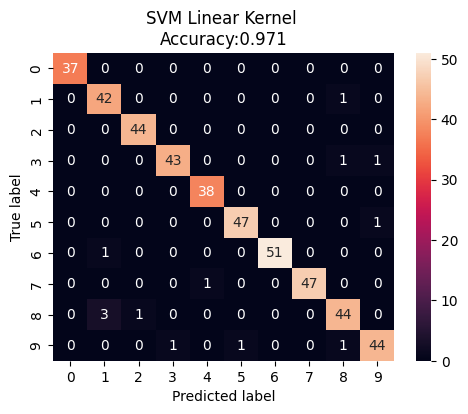

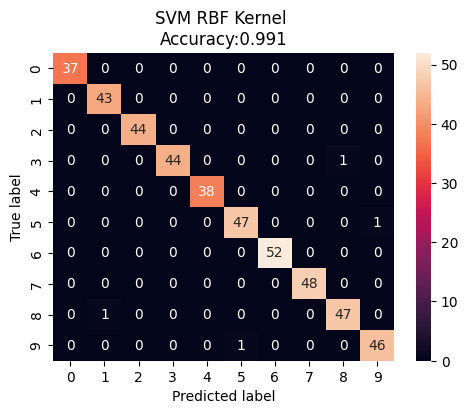

In [ ]:
dataset = load_digits()

X, y = dataset.data, dataset.target
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(X, y, random_state = 0)

svm = SVC(kernel='linear').fit(X_train_mc, y_train_mc)
svm_predicted_mc = svm.predict(X_test_mc)
confusion_mc = confusion_matrix(y_test_mc, svm_predicted_mc)
df_cm = pd.DataFrame(confusion_mc)

plt.figure(figsize=(5.5,4))
sns.heatmap(df_cm, annot=True)
plt.title(f'SVM Linear Kernel \nAccuracy:{accuracy_score(y_test_mc, svm_predicted_mc):.3f}')
plt.ylabel('True label')
plt.xlabel('Predicted label')

svm = SVC(kernel='rbf').fit(X_train_mc, y_train_mc)
svm_predicted_mc = svm.predict(X_test_mc)
confusion_mc = confusion_matrix(y_test_mc, svm_predicted_mc)
df_cm = pd.DataFrame(confusion_mc)

plt.figure(figsize=(5.5,4))
sns.heatmap(df_cm, annot=True)
plt.title(f'SVM RBF Kernel \nAccuracy:{accuracy_score(y_test_mc, svm_predicted_mc):.3f}')
plt.ylabel('True label')
plt.xlabel('Predicted label');

## Micro vs Macro Average

### Macro average
- Each class has equal weight;
1. Compute metric within each class
2. Average resulting metrics across classes
$AVG = \frac{Precision_1+Precision_2+...+Precision_N}{Number \,of \,classes}$

### Micro average:
- Each instance has equal weight;
- Largest classes have most influence.
1. Aggregate outcomes across all classes;
2. Compute metric with aggregate outcomes
$AVG = \frac{Correct\,Classifications}{Correct+Incorrect\,Classification}$

### Micro average vs Macro average
- If the classes have about the same number of instances, macro and micro average will be about the same;
- If some classes are much larger (more instances) than others, and you want to:
  - Weight your metric toward the largest ones, use micro-averaging;
  - Weight your metric toward the smallest ones, use macro-averaging.
- If the micro average is much lower than the macro average then examine the larger classes for poor metric performance;
- If the macro average is much lower than the micro average then examine the smaller classes for poor metric performance.



In [ ]:
print(f'Micro averaged precision = {precision_score(y_test_mc, svm_predicted_mc, average = 'micro'):.4f} (treat instances equally)')
print(f'Macro averaged precision = {precision_score(y_test_mc, svm_predicted_mc, average = 'macro'):.4f} (treat classes equally)')

Micro averaged precision = 0.9911 (treat instances equally)
Macro averaged precision = 0.9914 (treat classes equally)


In [ ]:
print(f'Micro averaged f1 = {f1_score(y_test_mc, svm_predicted_mc, average = 'micro'):.4f} (treat instances equally)')
print(f'Micro averaged f1 = {f1_score(y_test_mc, svm_predicted_mc, average = 'macro'):.4f} (treat classes equally)')

Micro averaged f1 = 0.9911 (treat instances equally)
Micro averaged f1 = 0.9914 (treat classes equally)


# Regression Evaluation

## Regression Metrics
- Typically r2_score is enough
  - Reminder: computes how well future instances will be predicted;
  - Best possible score is 1.0;
  - Constant prediction score is 0.
- Alternative metrics include:
  - mean_abolute_error (absolute difference of target and predicted values);
  - mean_squared_error (squared difference of target and predicted values);
  - median_absolute_error (robust to outliers).

Linear model, coefficients:  [-698.80206267]
Mean squared error (dummy): 58.31
Mean squared error (linear model): 56.03
r2_score (dummy): -0.00
r2_score (linear model): 0.06


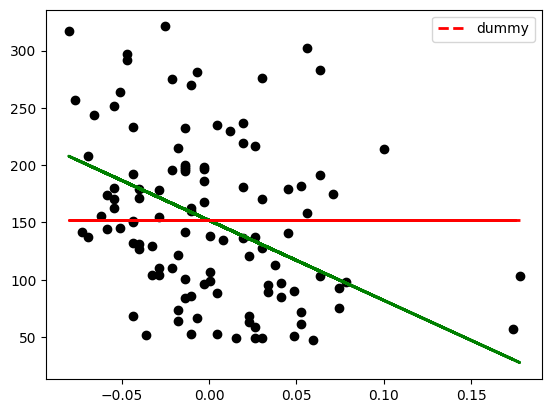

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn import datasets
from sklearn.linear_model import LinearRegression

diabetes = datasets.load_diabetes()

X = diabetes.data[:, None, 6]
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

lm = LinearRegression().fit(X_train, y_train)
lm_dummy_mean = DummyRegressor(strategy = 'mean').fit(X_train, y_train)

y_predicted = lm.predict(X_test)
y_predict_dummy_mean = lm_dummy_mean.predict(X_test)

print('Linear model, coefficients: ', lm.coef_)
print(f'Mean squared error (dummy): {mean_absolute_error(y_test, y_predict_dummy_mean):.2f}')
print(f'Mean squared error (linear model): {mean_absolute_error(y_test, y_predicted):.2f}')
print(f'r2_score (dummy): {r2_score(y_test, y_predict_dummy_mean):.2f}')
print(f'r2_score (linear model): {r2_score(y_test, y_predicted):.2f}')

plt.scatter(X_test, y_test, color='black')
plt.plot(X_test, y_predicted, color='green',linewidth=2)
plt.plot(X_test, y_predict_dummy_mean, color='red',linestyle='dashed',linewidth=2, label='dummy')
plt.legend();

## Dummy Regressor
The DummyRegressor class implements four simple baseline rules for regression, using the strategy parameter:
- Mean;
- Median;
- Quantile;
- Constant (choosen by the user).

# Model Selection: Optimizing Classifiers for Different Evaluation Metrics



## Cross validation example

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

dataset = load_digits()
X, y = dataset.data, dataset.target == 1
clf = SVC(kernel='linear')

print('Cross validation (accuracy)', cross_val_score(clf,X,y, cv=5))
print('Cross validation (AUC)', cross_val_score(clf, X, y, scoring='roc_auc'))
print('Cross validation (recall)', cross_val_score(clf, X, y, scoring ='recall'))

Cross validation (accuracy) [0.91944444 0.98611111 0.97214485 0.97493036 0.96935933]
Cross validation (AUC) [0.9641871  0.9976571  0.99372205 0.99699002 0.98675611]
Cross validation (recall) [0.81081081 0.89189189 0.83333333 0.83333333 0.83333333]


## Grid search example



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

clf = SVC(kernel='rbf')
grid_values = {'gamma': [0.001, 0.01, 0.05, 0.1, 1, 1, 10, 100]}

grid_clf_acc = GridSearchCV(clf, param_grid=grid_values)
grid_clf_acc.fit(X_train, y_train)
y_decision_fn_scores_acc = grid_clf_acc.decision_function(X_test)

print(f'Grid best parameter (max accuracy): {grid_clf_acc.best_params_}')
print(f'Grid best score (accuracy): {grid_clf_acc.best_score_}')

grid_clf_auc = GridSearchCV(clf, param_grid=grid_values, scoring='roc_auc')
grid_clf_auc.fit(X_train, y_train)
y_decision_fn_scores_auc = grid_clf_acc.decision_function(X_test)

print(f'Test set AUC: {roc_auc_score(y_test, y_decision_fn_scores_auc)}')
print(f'Grid best parameter (max AUC): {grid_clf_auc.best_params_}')
print(f'Grid best score (AUC): {grid_clf_auc.best_score_}')

Grid best parameter (max accuracy): {'gamma': 0.001}
Grid best score (accuracy): 0.9985157648354676
Test set AUC: 0.99982858122393
Grid best parameter (max AUC): {'gamma': 0.001}
Grid best score (AUC): 1.0


## Evaluation metrics supported for model selection

In [ ]:
from sklearn.metrics._scorer import _SCORERS

sorted(list(_SCORERS.keys()))

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

## Optimizing a classifier using different evaluation metrics


In [ ]:
!git clone https://github.com/ArthurCBx/Applied_MachineLearning_in_Python.git

Cloning into 'Applied_MachineLearning_in_Python'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 54 (delta 7), reused 29 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 12.05 MiB | 9.00 MiB/s, done.
Resolving deltas: 100% (7/7), done.


Grid best parameter (max precision): {'class_weight': {1: 2}}
Grid best score (precision): 0.5282422969187676
Grid best parameter (max recall): {'class_weight': {1: 50}}
Grid best score (recall): 0.9285714285714285
Grid best parameter (max f1): {'class_weight': {1: 3}}
Grid best score (f1): 0.5154614886280114
Grid best parameter (max roc_auc): {'class_weight': {1: 4}}
Grid best score (roc_auc): 0.8921920295081366


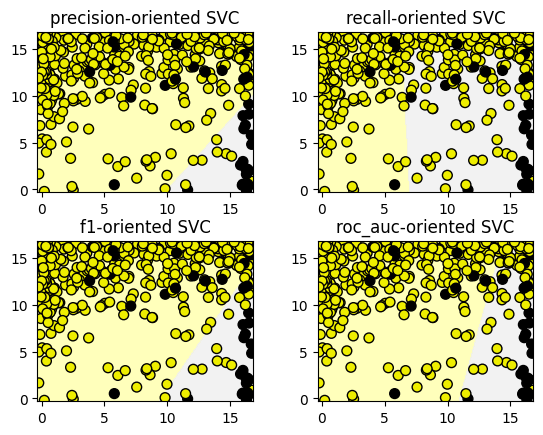

In [ ]:
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier_subplot

X, y = dataset.data, dataset.target == 1
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

jitter_delta = 0.25
X_twovar_train = X_train[:, [20,59]] + np.random.rand(X_train.shape[0], 2) - jitter_delta
X_twovar_test = X_test[:, [20,59]] + np.random.rand(X_test.shape[0], 2) - jitter_delta

clf = SVC(kernel='linear').fit(X_twovar_train, y_train)
grid_values = {'class_weight': ['balanced', {1:2}, {1:3}, {1:4}, {1:5}, {1:10}, {1:20}, {1:50}]}
plt.figure()

for i, eval_metric in enumerate(('precision', 'recall', 'f1', 'roc_auc')):
  grid_clf_custom = GridSearchCV(clf, param_grid=grid_values, scoring=eval_metric)
  grid_clf_custom.fit(X_twovar_train, y_train)
  print('Grid best parameter (max {0}): {1}'.format(eval_metric, grid_clf_custom.best_params_))
  print('Grid best score ({0}): {1}'.format(eval_metric, grid_clf_custom.best_score_))

  plt.subplots_adjust(wspace=0.3, hspace=0.3)
  plot_class_regions_for_classifier_subplot(grid_clf_custom, X_twovar_test, y_test,
                                            None, None, None, plt.subplot(2, 2, i + 1))
  plt.title(eval_metric + '-oriented SVC')

plt.show()

## Precision-recall curve for the default SVC classifier (with balanced class weights)

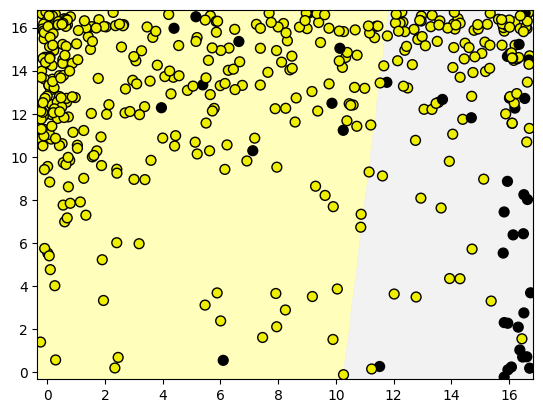

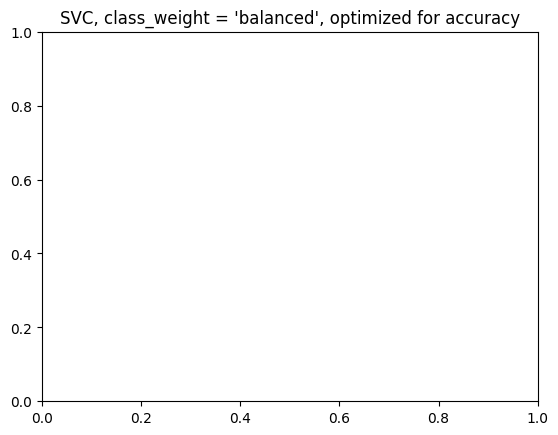

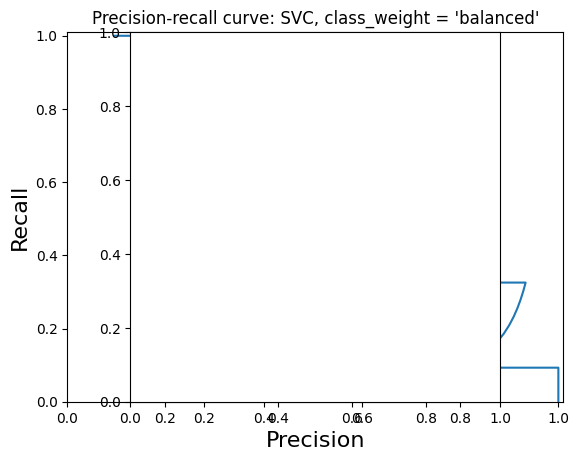

At zero threshold, precision: 0.22, recall: 0.74


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier
from sklearn.svm import SVC

dataset = load_digits()
X, y = dataset.data, dataset.target == 1
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# create a two-feature input vector matching the example plot above
jitter_delta = 0.25
X_twovar_train = X_train[:,[20,59]]+ np.random.rand(X_train.shape[0], 2) - jitter_delta
X_twovar_test  = X_test[:,[20,59]] + np.random.rand(X_test.shape[0], 2) - jitter_delta

clf = SVC(kernel='linear', class_weight='balanced').fit(X_twovar_train, y_train)

y_scores = clf.decision_function(X_twovar_test)

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
closest_zero = np.argmin(np.abs(thresholds))
closest_zero_p = precision[closest_zero]
closest_zero_r = recall[closest_zero]

plot_class_regions_for_classifier(clf, X_twovar_test, y_test)
plt.title("SVC, class_weight = 'balanced', optimized for accuracy")
plt.show()

plt.figure()
plt.xlim([0.0, 1.01])
plt.ylim([0.0, 1.01])
plt.title ("Precision-recall curve: SVC, class_weight = 'balanced'")
plt.plot(precision, recall, label = 'Precision-Recall Curve')
plt.plot(closest_zero_p, closest_zero_r, 'o', markersize=12, fillstyle='none', c='r', mew=3)
plt.xlabel('Precision', fontsize=16)
plt.ylabel('Recall', fontsize=16)
plt.axes().set_aspect('equal')
plt.show()
print('At zero threshold, precision: {:.2f}, recall: {:.2f}'
      .format(closest_zero_p, closest_zero_r))

## Train, Validation and Test Framework for Model Selection and Evaluation

- Using only cross-validation or a test set to do model selection may lead to more subtle overfitting/optimistic generalization estimates;
- Instead, use three data splits:
  1. Training set (model building);
  2. Validation set (model selection);
  3. Teste set (final evaluation).

- In practice:
  - Create an initial training/test split;
  - Do cross-validation on the training data for model/parameter selection;
  - Save the held-out test set for final model evaluation.

# Concluding Notes
- Accuracy is often not the right evaluation metric for many real-world machine learning task:
  - False positives and false negatives may need to be treated very differently;
  - Make sure you understand the needs of your application and choose an evaluation metric that matches your application, user, or business goals.
- Examples of additional evaluation methods include:
  - Learning curve: How much does accuracy (or other metric) change as a function of the amount of training data?
  - Sensitivity analysis: How much does accuracy (or other metric) change as a function of key learning parameter values?

# Model Calibration

## What is model calibration?
- A **calibrated model** outputs prediction probabilities that are close to real-world observed probabilities.
- Familiar example from weather prediction:
  - Suppose for all the days that a meteorologist predicted 100% chance of rain, it actually rained only 50% of time;
  - In this case, their probability estimate (100%) does not match the proportion that's actually observed (50%) and thus is **not calibrated**

## Calibration: ensuring accurate output probabilities

- A meteorologists's predictions are calibrated if:
  - Across all the days where the weatherperson predicts it will rain with probability R%, it actually does rain R% of the time.

- Predicted probability: the meteorologits predicts R% chance of rain;
- Empirical probability: the actual observed proportion of days it rained when the meteorologits predicted R% chance of rain.

## Calibration applied to ML
- A machine learning model may also have calibration issues.
- Binary classifier: Given an instance $x_i$ with 0/1 label $y_i$, a predictor $f(x_i)$ is calibrated if:
  - Across all the data points where the predictor 'belongs to class y=1' with probability R%, the data point actually does belong to class ' exactly R% of the time.
- The predicted probability p from the predictor matches the empirical probability.


## Why is calibration important?
- Many scenarios depend on having accurate prediction probabilities, such as decision making.
- What scenarios may not require calibration?
  - Non-probabilistic framework;
  - Relative prediction, e.g. ranking, using model prediction score.

- Miscalibrated models are common in machine learning
  - You should not assume a model is calibrated 'out of the box'
- For estimators that don't have a `predict_proba` method, calibration is a way to get output probabilities.

## Visualing model calibration with calibration curves (reliability curves)
Actual observed % of times it rained when prediction p ("empirical probability")

## How can we ensure our predictor is calibrated?
- Treat the model like a 'black box': train a calibration function that learns to correct/imporve the output prediction score of an existing predictor to turn it into a calibrated predictor;
- A good calibration function should ideally be strictly monotonic (always increasing) to preserve the original prediction rankings:
  - if the raw (non probability) score for item A < item B then we want prediction probability for item A < prediction probability for item B.

- Widely-used calibration methods include:
  - Platt scaling (sigmoid calibration);
  - Isotonic regression.

### Sigmoid calibration
- Suppose you want your classifier f(x) to output a probability $Pr[Y_i = 1]$ that data point x belongs to 'class 1'.
- However, the classifier f(x) only provides output numbers that are uncalibrated raw prediction scores

- **Idea** : Map these uncalibrated scores f(x) to probabilities by (1) using a linear transformation followed by (2) application of a logistic function:
$P(y=1|x) = \frac{1}{1+exp(Af(x)+B)}$
- Tune A and B to maximize calibration accuracy (getting the raliability curve as close as possible to the line y=x in the plot);
- Platt scalling is especially effective for maximum-margin methods such as SVMs or boosted trees that already tend to have sigmoidal distortions in their predicted probabilities.


### Isotonic Regression
1. Plot the raw score prediction f(x) of soft classifier against the actual fraction Y = 1 (empirical probability);
2. Perform isotonic regression to get g. Guarantees a (non-strictly) increasing function g.
3. Use g • f(x) = g(f(x)) to produce calibrated probabilities from the raw scores f(x)

- Compare isotonic calibration with sigmoid scalling:
  - Sigmoid restricted to using "S" shape;
  - Isotonic can fit any bias shape: it's a more powerful method, but prone to overfittin when data is scarce

## Calibration in scikit-learn

### `sklearn.calibration.CalibratedClassifierCV`
- Pass the base classifier you want to calibrate, calibration method and bumber of cross-validation (CV in the name of the module) folds to use for tuning;
- Creates a calibrated version of the input classifier;
- Supports two regressors: sigmoid and isotonic.

### `sklearn.calibration.calibration_curve`
- Pass the array of true target values and the corresponding probabilities of the positive class;
- This function will bin the given examples and comput the empirical and predicted probabilities for examples in each bin;
- Newer versions of sklearn: CalibrationDisplay

## CalibratedClassifierCV with an already-fitted classifier
- cv = 'prefit': data is not split: all provided data (calibration set) is used to fit the regressor. You must ensure the calibration data (for fitting the calibration regressor) is disjoint from the training set (for fitting the underlying prediction model);
- The 'ensemble' setting is ignored if you specify 'prefit'

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

X, y = make_classification(n_samples=1000, n_features=2,
                             n_redundant=0, random_state=0)

X_train, X_calib, y_train, y_calib = train_test_split(X, y, random_state=0)

base_clf = GaussianNB()
base_clf.fit(X_train, y_train)

calibrated_clf = CalibratedClassifierCV(estimator=base_clf, cv='prefit')
calibrated_clf.fit(X_calib, y_calib)

calibrated_clf.predict_proba([[-0.5,0.5]])

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


array([[0.02497502, 0.97502498]])

## CalibratedClassifierCV: fitting and calibrating simultaneously

- Set 'cv' according to the cross-validation strategy you want.
  - Default (None): use 5-fold cross-validation (stratified if label y is binary or multi-class)

- Set the 'ensemble' parameter according to how you want to combine the results from the cross-validation folds.

In [ ]:
X, y = make_classification(n_samples=1000, n_features=2,
                             n_redundant=0, random_state=0)

base_clf = GaussianNB()
calibrated_clf = CalibratedClassifierCV(base_clf, cv=5)
calibrated_clf.fit(X, y)
calibrated_clf.predict_proba(X)[:5,:]

array([[0.94825308, 0.05174692],
       [0.03386375, 0.96613625],
       [0.03443204, 0.96556796],
       [0.03379851, 0.96620149],
       [0.03717963, 0.96282037]])

In [ ]:
print(calibrated_clf.calibrated_classifiers_)
# This shows that it consists of 5 different models, 1 for each cv folder

[<sklearn.calibration._CalibratedClassifier object at 0x7e3f46b8b2f0>, <sklearn.calibration._CalibratedClassifier object at 0x7e3f46b88bc0>, <sklearn.calibration._CalibratedClassifier object at 0x7e3f46b8a150>, <sklearn.calibration._CalibratedClassifier object at 0x7e3f46b8ade0>, <sklearn.calibration._CalibratedClassifier object at 0x7e3f46b96390>]


## How to integrate calibration into your workflow?
- Does calibration matter for your application? Consider using if:
  - You use a probabilistic framework;
  - Probabilistic outputs (confidence/risk estimates) are important to your application.
- Important; Always run the calibration step on a separate validation set that is different from the training set
  - Otherwise adding the calibration step could worsen overfitting problems;
- Other technical considerations:
  - The calibration function should minimize a strictly proper scoring rule;
  - A good calibration function should also maximize a 'sharpness' properly: make predictions far from the global probability average.